# Trigonometric Decomposition of 3D Lattice Potential using SymPy

This notebook decomposes the 3D lattice potential phase expression:
$$\cos(C(r_x + r_y + r_z) + \phi)$$
first into standard product terms involving both cosines $\cos(C r_i)$ and sines $\sin(C r_i)$, and then applies the phase-shift identity:
$$\sin(C r_i) = \cos\left(C r_i - \frac{\pi}{2}\right)$$
to convert spatial sine terms into phase-shifted cosines.

It also provides utilities to substitute custom values for $C$ and $\phi$ into the resulting expressions.


Original Expression:



1. Original Decomposed Expression (with both Sines and Cosines):


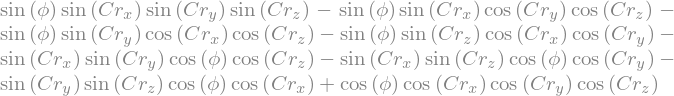

In [8]:
import sympy as sp
from IPython.display import display

# Initialize pretty printing in Jupyter notebook
sp.init_printing()

# Define real symbols
r_x, r_y, r_z, C, phi = sp.symbols('r_x r_y r_z C phi', real = True)

# Define target expression
expr = sp.cos(C * (r_x + r_y + r_z) + phi)

# 1. Expand argument multiplication: cos(C*r_x + C*r_y + C*r_z + phi)
# 2. Apply trigonometric angle sum formulas via expand_trig()
# 3. Fully expand to obtain sum of products of cosine/sine terms
expanded_expr = sp.expand(sp.expand_trig(expr.expand(mul = True)))

print("Original Expression:")
display(expr)

print("\n1. Original Decomposed Expression (with both Sines and Cosines):")
display(expanded_expr)


2. Phase-Shifted Cosine Expression [sin(C*r_i) -> cos(C*r_i - pi/2)]:


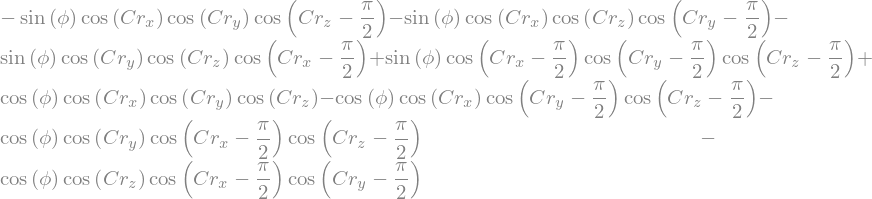

In [9]:
# Substitute sin(C*r_i) with phase-shifted cosine cos(C*r_i - pi/2)
# Using sp.UnevaluatedExpr on the argument prevents SymPy from automatically simplifying cos(x - pi/2) back to sin(x)
phase_shifted_expr = expanded_expr.replace(
    lambda e: isinstance(e, sp.sin) and e.args[0] != phi,
    lambda e: sp.cos(sp.UnevaluatedExpr(e.args[0] - sp.pi / 2))
)

print("2. Phase-Shifted Cosine Expression [sin(C*r_i) -> cos(C*r_i - pi/2)]:")
display(phase_shifted_expr)


Example 1 (C = pi, phi = 0):
Original (sines & cosines):


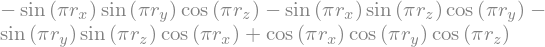

Phase-shifted (cosines):


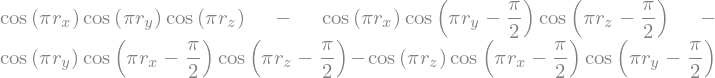


Example 2 (C = pi/2, phi = pi/4):
Original (sines & cosines):


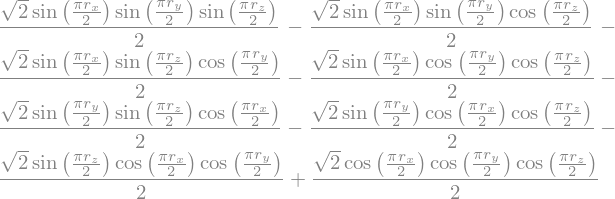

Phase-shifted (cosines):


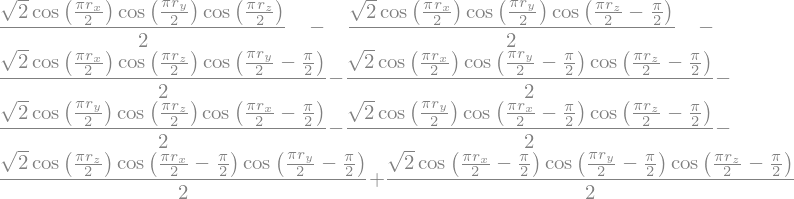

In [10]:
def substitute_params(target_expr, C_val = None, phi_val = None):
    """
    Substitutes values for C and phi into a SymPy expression.
    
    Args:
        target_expr (sympy.Expr): Trigonometric expression.
        C_val (float, int, or sympy.Expr, optional): Value to substitute for C.
        phi_val (float, int, or sympy.Expr, optional): Value to substitute for phi.
        
    Returns:
        substituted_expr (sympy.Expr): Expression with C and phi substituted.
    """
    subs_dict = {}
    if C_val is not None:
        subs_dict[C] = C_val
    if phi_val is not None:
        subs_dict[phi] = phi_val
        
    return target_expr.subs(subs_dict)

# Example 1: Substitute C = pi, phi = 0
sub_orig_1 = substitute_params(expanded_expr, C_val = sp.pi, phi_val = 0)
sub_shifted_1 = substitute_params(phase_shifted_expr, C_val = sp.pi, phi_val = 0)

print("Example 1 (C = pi, phi = 0):")
print("Original (sines & cosines):")
display(sub_orig_1)
print("Phase-shifted (cosines):")
display(sub_shifted_1)

# Example 2: Substitute C = pi/2, phi = pi/4
sub_orig_2 = substitute_params(expanded_expr, C_val = sp.pi / 2, phi_val = sp.pi / 4)
sub_shifted_2 = substitute_params(phase_shifted_expr, C_val = sp.pi / 2, phi_val = sp.pi / 4)

print("\nExample 2 (C = pi/2, phi = pi/4):")
print("Original (sines & cosines):")
display(sub_orig_2)
print("Phase-shifted (cosines):")
display(sub_shifted_2)


Result for C = pi/2, phi = 2*pi/3:

Original Expression (sines & cosines):


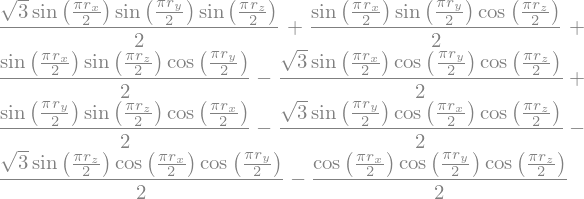


Phase-Shifted Expression (cosines):


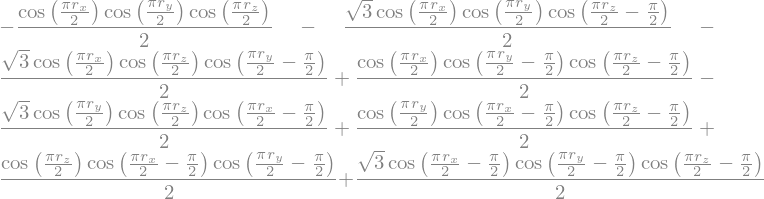

In [12]:
# User Input: Modify C_user and phi_user below to test custom values
C_user = sp.pi / 2
phi_user = sp.pi * 2 / 3

# Perform substitution into both original and phase-shifted expressions
user_orig_result = substitute_params(expanded_expr, C_val = C_user, phi_val = phi_user)
user_shifted_result = substitute_params(phase_shifted_expr, C_val = C_user, phi_val = phi_user)

print(f"Result for C = {C_user}, phi = {phi_user}:")
print("\nOriginal Expression (sines & cosines):")
display(user_orig_result)
print("\nPhase-Shifted Expression (cosines):")
display(user_shifted_result)
